In [2]:
import finesse
import numpy as np
import matplotlib.pyplot as plt
from finesse.analysis.actions import Xaxis

finesse.configure(plotting=True)

## Coupled Cavity

- **PRC** (PRM ↔ ITM) — the power recycling cavity
- **Arm** (ITM ↔ ETM) — the arm cavity

The two readouts:

- **REFL** — field at `PRM.p1.o`
- **POP**  — field at `PRM.p2.o`

Both detectors are demodulated at the 80 MHz modulation frequency.

### Matrix construction

The matrix is built column by column by perturbing one DOF at a time and
reading the slope of both detectors at that operating point:


$$
\begin{bmatrix} \text{REFL} \\ \text{POP} \end{bmatrix}
=
\begin{bmatrix} x_{11} & x_{12} \\ x_{21} & x_{22} \end{bmatrix}
\begin{bmatrix} \text{Arm} \\ \text{PRC} \end{bmatrix}
$$

\
Expectation: $|x_{11}| \gg |x_{12}|$ and $|x_{22}| \gg |x_{21}|$,
since REFL and POP are each designed to be primarily sensitive to one DOF. But it cannot be perfectly blind as ITM is common between the two cavities!

Sensing Matrix
[[-7.96091700e+00 -5.25385467e-03]
 [ 1.13882638e+00  9.44349883e-03]]


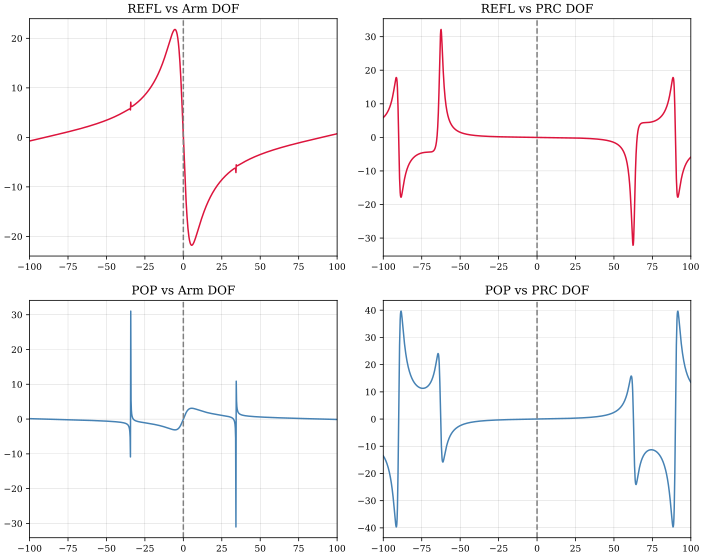

In [17]:
finesse.configure(plotting=True)

#Base model
def build_model():

    model = finesse.Model()

    model.parse(f'''
        l laser1 P=125

        s s1 laser1.p1 mod.p1 L=1
        modulator mod f=80M midx=0.3 order=1
        s s2 mod.p2 PRM.p1 L=9

        # Power Recycling Mirror
        m PRM R=0.9 T=0.1 phi=0

        # Power Recycling Cavity
        s s_prc PRM.p2 ITM.p1 L=40

        # Input Test Mass
        m ITM R=0.99 T=0.01 phi=0

        # Arm cavity
        s s_arm ITM.p2 ETM.p1 L=4000

        # End Test Mass
        m ETM R=1.0 T=0.0 phi=0

        # Reflection port detector
        pd1 REFL PRM.p1.o 80M 90

        # Pick-off port detector
        pd1 POP PRM.p2.o 80M 90
    ''')

    return model

#Slope = d(signal)/d(length)
def get_slope(x, signal):
    center = np.argmin(np.abs(x))
    return (
        signal[center + 1] - signal[center - 1]
    ) / (
        x[center + 1] - x[center - 1]
    )


#arm DoF (sweeping just ETM)
model_arm = build_model()
out_arm = model_arm.run(Xaxis("ETM.phi", "lin", -100, 100, 1000))
x_arm = out_arm.x[0]

refl_arm = get_slope(x_arm, out_arm["REFL"]) # REFL
pop_arm = get_slope(x_arm, out_arm["POP"]) # POP


#PRC DoF (sweeping just PRM)
model_prc = build_model()
out_prc = model_prc.run(Xaxis("PRM.phi", "lin", -100, 100, 1000))
x_prc = out_prc.x[0]


refl_prc = get_slope(x_prc, out_prc["REFL"]) #REFL
pop_prc = get_slope(x_prc, out_prc["POP"]) #POP

#Sensing Matrix

#           Arm DOF      PRC DOF
#
# REFL   [ dREFL/dARM   dREFL/dPRC ]
#
# POP    [ dPOP/dARM    dPOP/dPRC ]


sensing_matrix = np.array([
    [refl_arm, refl_prc],
    [pop_arm,  pop_prc]
])

print("Sensing Matrix")
print(sensing_matrix)




fig, axes = plt.subplots(2, 2, figsize=(10,8))

axes[0,0].plot(x_arm, out_arm["REFL"], color="crimson")
axes[0,0].set_title("REFL vs Arm DOF")
axes[0,0].axvline(0, ls="--", c="gray")

axes[1,0].plot(x_arm, out_arm["POP"], color="steelblue")
axes[1,0].set_title("POP vs Arm DOF")
axes[1,0].axvline(0, ls="--", c="gray")

axes[0,1].plot(x_prc, out_prc["REFL"], color="crimson")
axes[0,1].set_title("REFL vs PRC DOF")
axes[0,1].axvline(0, ls="--", c="gray")

axes[1,1].plot(x_prc, out_prc["POP"], color="steelblue")
axes[1,1].set_title("POP vs PRC DOF")
axes[1,1].axvline(0, ls="--", c="gray")

for ax in axes.flat:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Result and open discrepancy

Measured matrix:

$$
\begin{bmatrix} -7.96 & -0.00525 \\ 1.14 & 0.00944 \end{bmatrix}
$$

The REFL row is okay but the POP row is also arm dominant! This does not match the expected diagonal-dominance pattern.

Sensing Matrix
[[-0.71754038 -0.02316663]
 [ 0.12217834  0.02316663]]


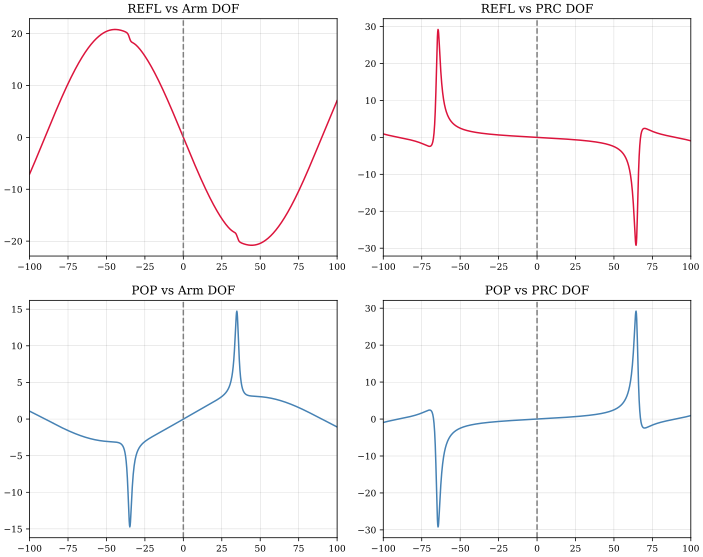

In [15]:
finesse.configure(plotting=True)

#Base model
def build_model():

    model = finesse.Model()

    model.parse(f'''
        l laser1 P=125

        s s1 laser1.p1 mod.p1 L=1
        modulator mod f=80M midx=0.3 order=1
        s s2 mod.p2 PRM.p1 L=9

        # Power Recycling Mirror
        m PRM R=0.9 T=0.1 phi=0

        # Power Recycling Cavity
        s s_prc PRM.p2 ITM.p1 L=40

        # Input Test Mass
        m ITM R=0.9 T=0.1 phi=0

        # Arm cavity
        s s_arm ITM.p2 ETM.p1 L=4000

        # End Test Mass
        m ETM R=0.9 T=0.1 phi=0

        # Reflection port detector
        pd1 REFL PRM.p1.o 80M 90

        # Pick-off port detector
        pd1 POP PRM.p2.o 80M 90
    ''')

    return model

#Slope = d(signal)/d(length)
def get_slope(x, signal):
    center = np.argmin(np.abs(x))
    return (
        signal[center + 1] - signal[center - 1]
    ) / (
        x[center + 1] - x[center - 1]
    )


#arm DoF (sweeping just ETM)
model_arm = build_model()
out_arm = model_arm.run(Xaxis("ETM.phi", "lin", -100, 100, 1000))
x_arm = out_arm.x[0]

refl_arm = get_slope(x_arm, out_arm["REFL"]) # REFL
pop_arm = get_slope(x_arm, out_arm["POP"]) # POP


#PRC DoF
model_prc = build_model()
out_prc = model_prc.run(Xaxis("PRM.phi", "lin", -100, 100, 1000))
x_prc = out_prc.x[0]


refl_prc = get_slope(x_prc, out_prc["REFL"]) #REFL
pop_prc = get_slope(x_prc, out_prc["POP"]) #POP

#Sensing Matrix

#           Arm DOF      PRC DOF
#
# REFL   [ dREFL/dARM   dREFL/dPRC ]
#
# POP    [ dPOP/dARM    dPOP/dPRC ]


sensing_matrix = np.array([
    [refl_arm, refl_prc],
    [pop_arm,  pop_prc]
])

print("Sensing Matrix")
print(sensing_matrix)


#Plots
fig, axes = plt.subplots(2, 2, figsize=(10,8))

axes[0,0].plot(x_arm, out_arm["REFL"], color="crimson")
axes[0,0].set_title("REFL vs Arm DOF")
axes[0,0].axvline(0, ls="--", c="gray")

axes[1,0].plot(x_arm, out_arm["POP"], color="steelblue")
axes[1,0].set_title("POP vs Arm DOF")
axes[1,0].axvline(0, ls="--", c="gray")

axes[0,1].plot(x_prc, out_prc["REFL"], color="crimson")
axes[0,1].set_title("REFL vs PRC DOF")
axes[0,1].axvline(0, ls="--", c="gray")

axes[1,1].plot(x_prc, out_prc["POP"], color="steelblue")
axes[1,1].set_title("POP vs PRC DOF")
axes[1,1].axvline(0, ls="--", c="gray")

for ax in axes.flat:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()